# BlackboxNLP concept dataset (v2): WordNet supersense sample

Builds a stratified concept inventory for the steerability study.

- **Frame:** all single-word, noun-dominant WordNet lemmas, grouped by *supersense* (lexicographer file).
- **Excluded supersenses:** `noun.Tops` (hypernym roots, e.g. *entity* — steering toward these is ill-posed) and `noun.motive` (too small).
- **Per supersense:** 25 concepts, **stratified by Zipf frequency** (5 equal-frequency strata × 5 each) so each category spans the frequency range rather than clustering. Fixed seed → repeatable.
- **Independent variables per concept:** Zipf frequency, concreteness (Brysbaert 2014), age of acquisition (Kuperman 2012), polysemy (# WordNet noun senses), and # Llama-3.1 tokens.

Candidate pool requires a known Zipf value **and** presence in the concreteness and AoA norms, so all four variables are fully populated.

In [2]:
import os, re
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.data.path.insert(0, 'bbxdata/nltk_data')
from nltk.corpus import wordnet as wn
from wordfreq import zipf_frequency

SEED = 0                      # fixed for repeatability
PER_SUPERSENSE = 25
N_STRATA = 5                  # frequency strata per supersense (5 x 5 = 25)
EXCLUDE = {'noun.Tops', 'noun.motive'}
DATA_DIR = 'bbxdata'
OUT_CSV = os.path.join(DATA_DIR, 'bbx_wordnet_ds.csv')
rng = np.random.default_rng(SEED)

## 1. Load the psycholinguistic norms

In [3]:
# Concreteness (Brysbaert et al. 2014): tab-separated, columns Word / Conc.M
conc_df = pd.read_csv(os.path.join(DATA_DIR, 'concreteness_brysbaert2014.txt'),
                      sep='\t', usecols=['Word', 'Conc.M'])
conc = {str(w).lower(): m for w, m in zip(conc_df['Word'], conc_df['Conc.M'])}

# Age of acquisition (Kuperman et al. 2012): columns Word / Rating.Mean
aoa_df = pd.read_excel(os.path.join(DATA_DIR, 'AoA_ratings_Kuperman_et_al_BRM.xlsx'),
                       usecols=['Word', 'Rating.Mean'])
aoa = {str(w).lower(): m for w, m in zip(aoa_df['Word'], aoa_df['Rating.Mean'])}

print(f'concreteness norms: {len(conc):,} words')
print(f'AoA norms:          {len(aoa):,} words')

concreteness norms: 39,954 words
AoA norms:          31,124 words


## 2. Build the candidate pool
Each WordNet noun lemma is assigned to the supersense of its **dominant (first) noun sense**. Keep single alphabetic words that have a Zipf value and appear in both norm sets.

In [4]:
rows = []
seen = set()
for syn in wn.all_synsets('n'):
    for lemma in syn.lemma_names():
        w = lemma.lower()
        if w in seen or not re.fullmatch(r'[a-z]+', w):
            continue
        seen.add(w)
        dominant = wn.synsets(w, 'n')[0].lexname()   # supersense of the dominant sense
        if dominant in EXCLUDE:
            continue
        z = zipf_frequency(w, 'en')
        if z > 0 and w in conc and w in aoa:
            rows.append((w, dominant, z))

cand = pd.DataFrame(rows, columns=['concept', 'supersense', 'zipf'])
print(f'{len(cand):,} candidate concepts across {cand.supersense.nunique()} supersenses')
cand.supersense.value_counts().sort_values()

15,278 candidate concepts across 24 supersenses


supersense
noun.relation          102
noun.shape             112
noun.process           129
noun.phenomenon        169
noun.possession        207
noun.quantity          224
noun.time              237
noun.object            247
noun.feeling           255
noun.location          261
noun.plant             305
noun.body              307
noun.group             410
noun.animal            414
noun.food              420
noun.event             423
noun.substance         535
noun.cognition         751
noun.state             904
noun.attribute         967
noun.communication    1270
noun.act              1432
noun.artifact         2435
noun.person           2762
Name: count, dtype: int64

## 3. Stratified sample: 25 per supersense, stratified by Zipf
Within each supersense, candidates are sorted by Zipf and split into 5 equal-frequency strata; 5 are drawn from each stratum. Seeded → identical output every run.

In [5]:
def stratified_sample(df, n=PER_SUPERSENSE, k=N_STRATA, rng=rng):
    """Sample n rows stratified into k equal-frequency Zipf bands (n must be divisible by k)."""
    df = df.sort_values('zipf', kind='stable').reset_index(drop=True)
    per = n // k
    picks = []
    for stratum in np.array_split(df.index.values, k):
        take = min(per, len(stratum))
        picks.extend(rng.choice(stratum, size=take, replace=False).tolist())
    # top up if any stratum was short (won't happen here: every supersense has >100 candidates)
    if len(picks) < n:
        remaining = [i for i in df.index.values if i not in set(picks)]
        picks.extend(rng.choice(remaining, size=n - len(picks), replace=False).tolist())
    return df.loc[picks]

samples = [stratified_sample(cand[cand.supersense == ss])
           for ss in sorted(cand.supersense.unique())]   # sorted order => reproducible
ds = pd.concat(samples).reset_index(drop=True)
print(f'sampled {len(ds)} concepts ({ds.supersense.nunique()} supersenses x {PER_SUPERSENSE})')

sampled 600 concepts (24 supersenses x 25)


## 4. Add the remaining independent variables
Polysemy = # WordNet noun senses; tokens = Llama-3.1 sub-word pieces of the (space-prefixed) word.

In [6]:
# (i) concreteness, (ii) age of acquisition
ds['conc'] = ds['concept'].map(conc)
ds['aoa']  = ds['concept'].map(aoa)

# (iii) polysemy: number of WordNet noun senses
ds['polysemy'] = ds['concept'].map(lambda w: len(wn.synsets(w, 'n')))

# (iv) number of Llama-3.1 tokens (space-prefixed word, as it appears mid-sentence; no special tokens)
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained('meta-llama/Meta-Llama-3.1-8B-Instruct')
ds['n_tokens'] = ds['concept'].map(lambda w: len(tok(' ' + w, add_special_tokens=False)['input_ids']))

ds = ds[['concept', 'supersense', 'zipf', 'conc', 'aoa', 'polysemy', 'n_tokens']]
assert ds[['zipf', 'conc', 'aoa', 'polysemy', 'n_tokens']].notna().all().all(), 'unexpected NaNs'

## 5. Save

In [7]:
ds.to_csv(OUT_CSV, index=False)
print('saved ->', OUT_CSV)

saved -> bbxdata/bbx_wordnet_ds.csv


## 6. Inspect

In [8]:
print('rows:', len(ds))
ds.head(1)

rows: 600


,concept,supersense,zipf,conc,aoa,polysemy,n_tokens
0,infliction,noun.act,2.37,2.12,12.0,3,2


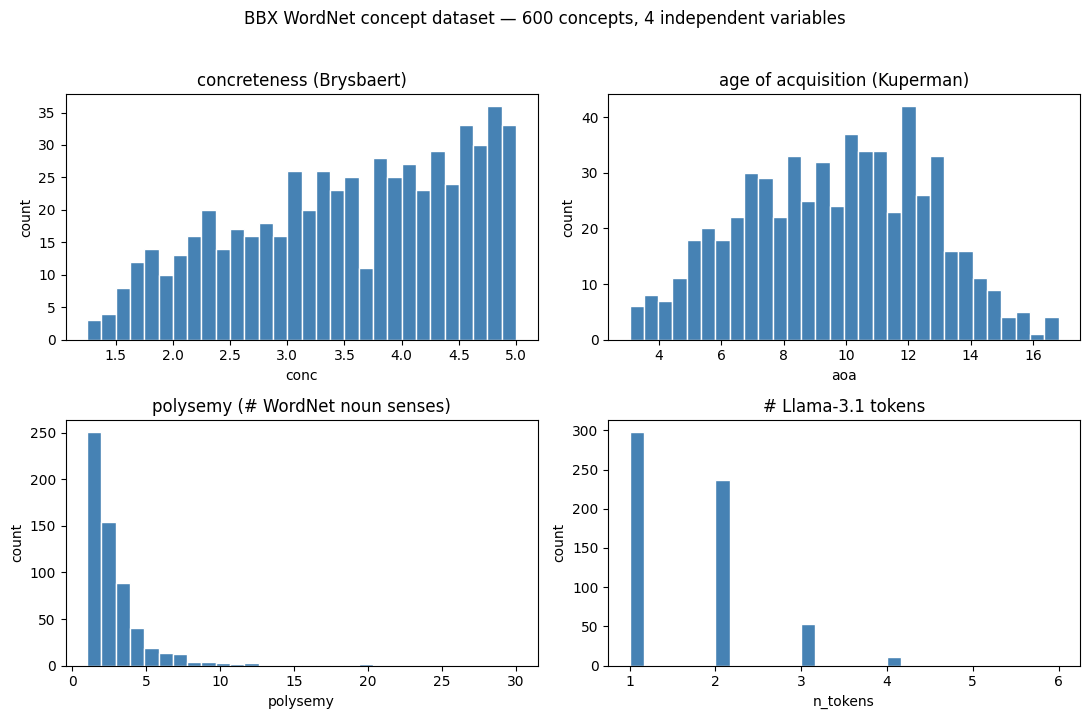

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
specs = [('conc', 'concreteness (Brysbaert)'),
         ('aoa', 'age of acquisition (Kuperman)'),
         ('polysemy', 'polysemy (# WordNet noun senses)'),
         ('n_tokens', '# Llama-3.1 tokens')]
for ax, (col, title) in zip(axes.ravel(), specs):
    ax.hist(ds[col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(col); ax.set_ylabel('count')
fig.suptitle(f'BBX WordNet concept dataset — {len(ds)} concepts, 4 independent variables', y=1.02)
fig.tight_layout()
plt.show()

## 7. Zipf frequency distribution

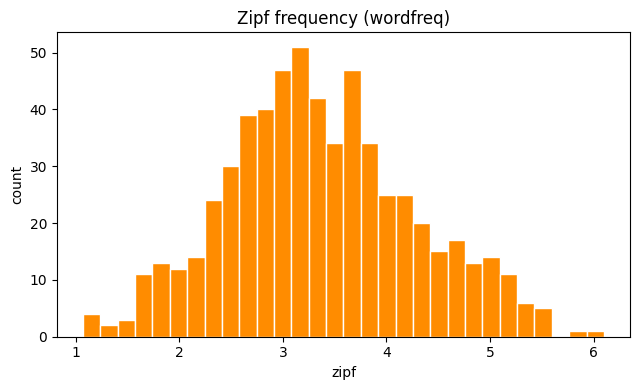

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(ds['zipf'], bins=30, color='darkorange', edgecolor='white')
ax.set_title('Zipf frequency (wordfreq)')
ax.set_xlabel('zipf'); ax.set_ylabel('count')
fig.tight_layout()
plt.show()

In [12]:
ds

,concept,supersense,zipf,conc,aoa,polysemy,n_tokens
0,infliction,noun.act,2.37,2.12,12.000000,3,2
1,redeye,noun.act,2.27,3.77,10.380000,1,2
2,downshift,noun.act,1.97,3.30,12.740000,2,2
3,acupressure,noun.act,2.03,3.53,14.440000,1,4
4,beautification,noun.act,2.52,2.22,11.200000,1,2
...,...,...,...,...,...,...,...
595,moment,noun.time,5.24,1.61,7.950000,6,1
596,tomorrow,noun.time,5.02,2.04,5.187988,2,1
597,month,noun.time,5.25,4.20,5.790000,2,1
598,leave,noun.time,5.34,2.53,5.580000,3,1


In [ ]:
# v3 additions: ontology covariates (kept, not filtered -- see paper design)
# is_instance: dominant synset is a named individual (WordNet instance_hypernyms)
# n_verb_senses: cross-POS ambiguity, companion covariate to polysemy
ds['is_instance'] = ds['concept'].map(lambda w: bool(wn.synsets(w,'n') and wn.synsets(w,'n')[0].instance_hypernyms()))
ds['n_verb_senses'] = ds['concept'].map(lambda w: len(wn.synsets(w,'v')))
ds.to_csv(OUT_CSV, index=False)
print('v3 columns added; instances:', ds.is_instance.sum())